In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

# 1. Charger les données
df = pd.read_csv('final_smart_farm_dataset.csv')

# 2. Convertir le Timestamp en objet datetime
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])

# 3. Trier par date (au cas où)
df = df.sort_values('TimeStamp')

df = df.loc[df['Coordinates'] == '[0, 1]']

# 4. Gérer les données manquantes (NaN)
# Pour le Deep Learning et la visualisation, l'interpolation linéaire
# est souvent la meilleure méthode pour les capteurs
df_clean = df.copy()
numeric_cols = ['N','P','K','green pixels','size','Air temp','Humidity','CO2','Leaf temp','Light intensity','Soil Moisture','IsProbed']
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='linear')

# Afficher les premières lignes
print("Aperçu des données :")
display(df_clean.head())

KeyError: "['N', 'P', 'K', 'green pixels', 'size', 'Air temp', 'Leaf temp', 'Light intensity', 'Soil Moisture'] not in index"

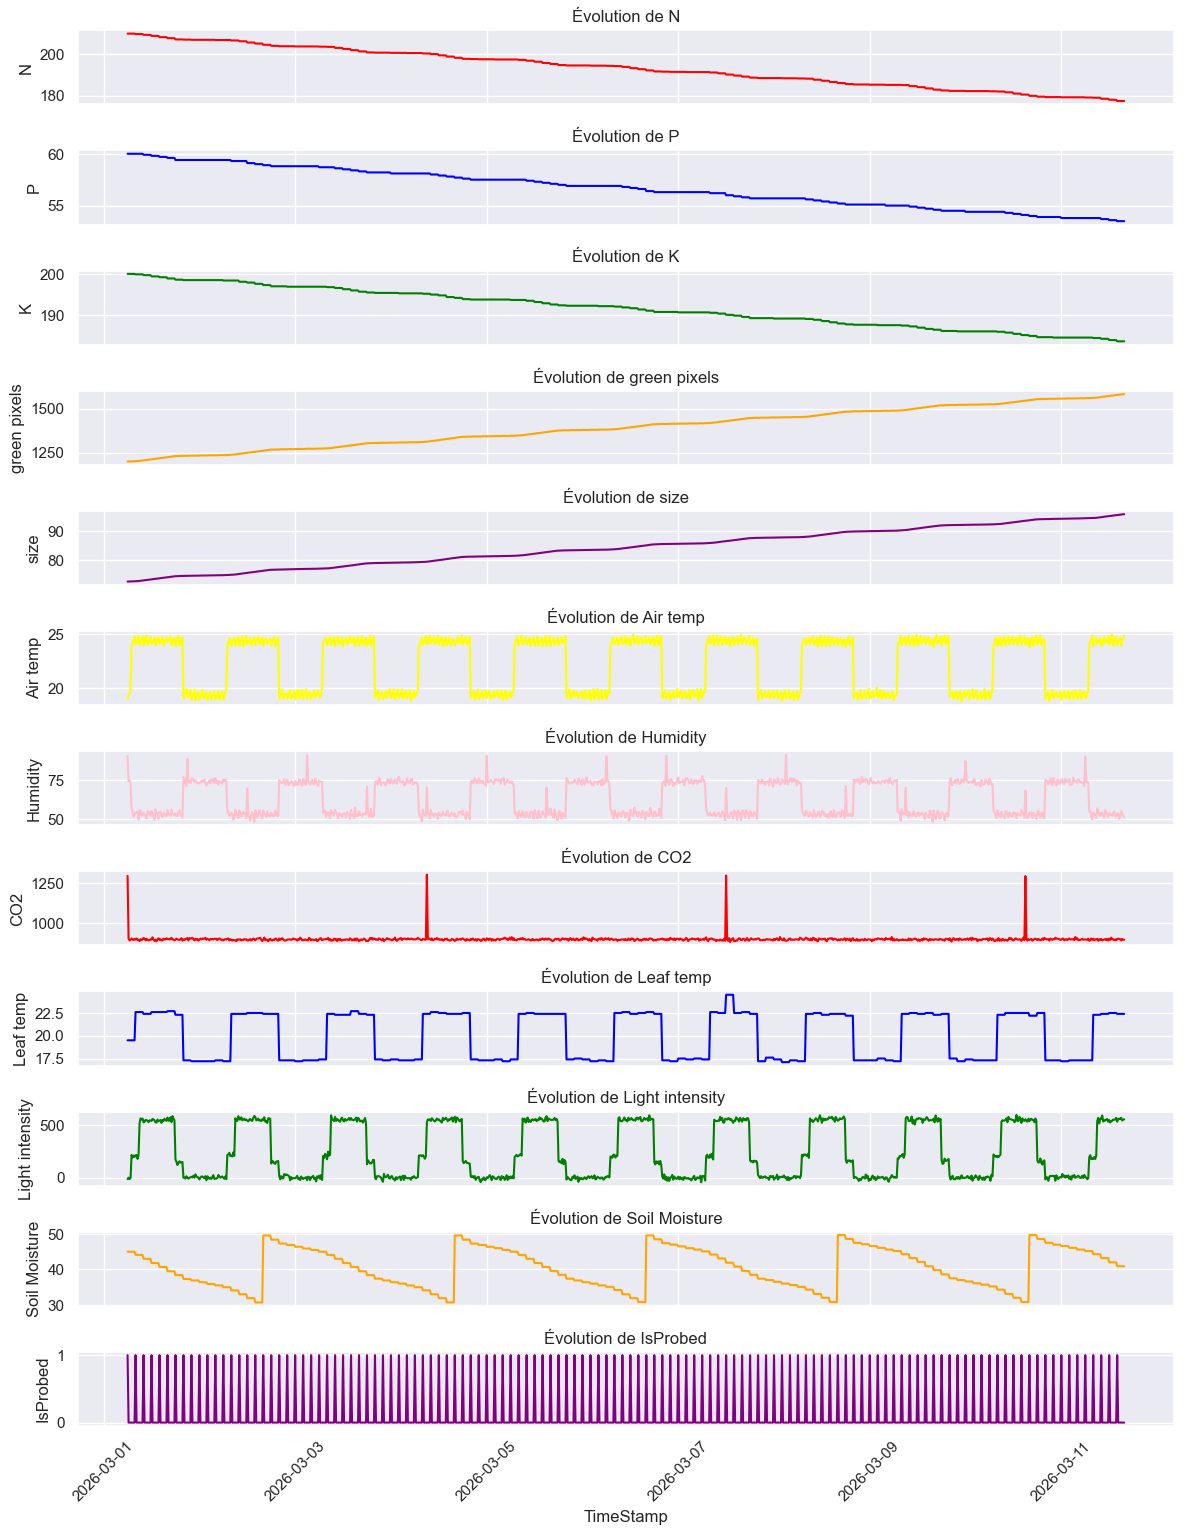

In [20]:
# Configuration du style
sns.set(style="darkgrid")
fig, axes = plt.subplots(nrows=12, ncols=1, figsize=(12, 15), sharex=True)

variables = ['N','P','K','green pixels','size','Air temp','Humidity','CO2','Leaf temp','Light intensity','Soil Moisture','IsProbed']
colors = ['red', 'blue', 'green', 'orange', 'purple','yellow','pink','red', 'blue', 'green', 'orange', 'purple']

for i, var in enumerate(variables):
    sns.lineplot(data=df_clean, x='TimeStamp', y=var, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Évolution de {var}', fontsize=12)
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [21]:
# Transformation des données pour Plotly (format long)
df_melted = df_clean.melt(id_vars=['TimeStamp'], value_vars=variables,
                          var_name='Capteur', value_name='Valeur')

fig = px.line(df_melted, x='TimeStamp', y='Valeur', color='Capteur',
              title='Visualisation Interactive des Capteurs',
              labels={'TimeStamp': 'Temps', 'Valeur': 'Mesure'})

# Ajout de curseurs pour naviguer dans le temps
fig.update_xaxes(rangeslider_visible=True)

fig.show()